In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from pathlib import Path

# Dataset configuration
DATA_DIR = Path("../data/casting_512x512")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load training data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    class_names=["ok_front", "def_front"],
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Load validation data
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    class_names=["ok_front", "def_front"],
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())

Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Found 1300 files belonging to 2 classes.
Using 260 files for validation.
Training batches: 33
Validation batches: 9


In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    layers.RandomContrast(0.10)
], name="data_augmentation")

In [12]:
model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels: 0-255 → 0-1
    layers.Rescaling(1.0 / 255),

    # Feature extraction
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Convert feature maps to feature vector
    layers.GlobalAveragePooling2D(),

    # Regularization
    layers.Dropout(0.40),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),

    # Binary classification
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="../models/best_casting_defect_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [15]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25


B:\DEEP_LEARNING\casting-quality-inspection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


33/33 ━━━━━━━━━━━━━━━━━━━━ 25s 668ms/step - accuracy: 0.5904 - loss: 0.6817 - precision: 0.5996 - recall: 0.9353 - val_accuracy: 0.6269 - val_loss: 0.6573 - val_precision: 0.6269 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 662ms/step - accuracy: 0.5952 - loss: 0.6648 - precision: 0.5948 - recall: 1.0000 - val_accuracy: 0.6269 - val_loss: 0.6265 - val_precision: 0.6269 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 649ms/step - accuracy: 0.5942 - loss: 0.6493 - precision: 0.5942 - recall: 1.0000 - val_accuracy: 0.6269 - val_loss: 0.6260 - val_precision: 0.6269 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 648ms/step - accuracy: 0.5962 - loss: 0.6401 - precision: 0.5957 - recall: 0.9968 - val_accuracy: 0.6269 - val_loss: 0.6812 - val_precision: 0.6269 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 652ms/step - accuracy: 0.6183

In [16]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])


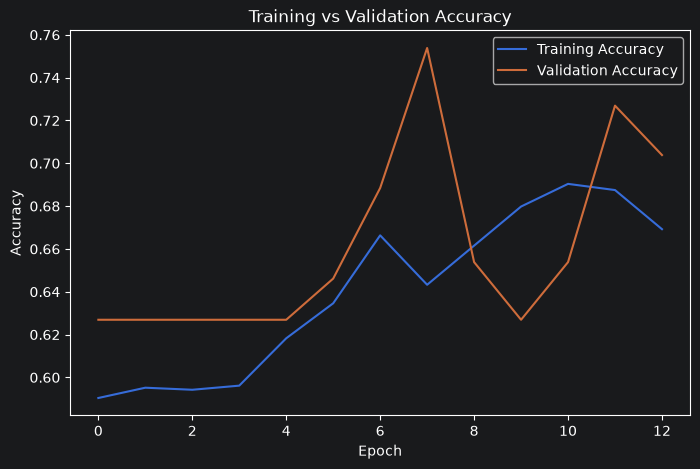

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

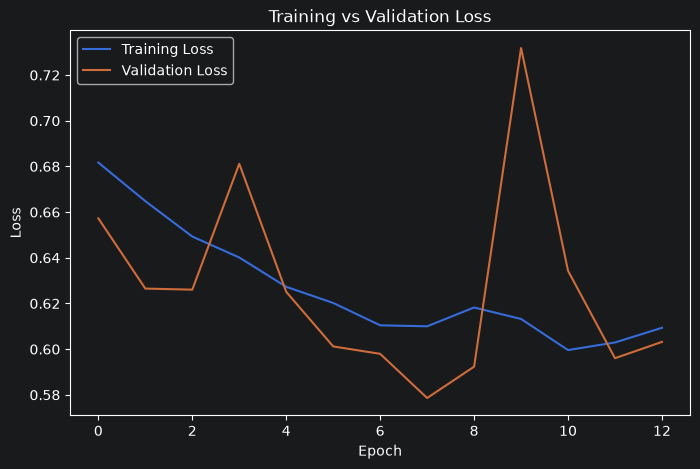

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [20]:
import numpy as np
best_epoch = np.argmin(history.history["val_loss"]) + 1

print("Best epoch:", best_epoch)
print(
    "Best validation loss:",
    history.history["val_loss"][best_epoch - 1]
)

print(
    "Validation accuracy at best epoch:",
    history.history["val_accuracy"][best_epoch - 1]
)

Best epoch: 8
Best validation loss: 0.5786172151565552
Validation accuracy at best epoch: 0.7538461685180664


In [21]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])


In [22]:
for i in range(len(history.history["loss"])):
    print(
        f"Epoch {i+1}: "
        f"loss={history.history['loss'][i]:.4f}, "
        f"acc={history.history['accuracy'][i]:.4f}, "
        f"val_loss={history.history['val_loss'][i]:.4f}, "
        f"val_acc={history.history['val_accuracy'][i]:.4f}"
    )

Epoch 1: loss=0.6817, acc=0.5904, val_loss=0.6573, val_acc=0.6269
Epoch 2: loss=0.6648, acc=0.5952, val_loss=0.6265, val_acc=0.6269
Epoch 3: loss=0.6493, acc=0.5942, val_loss=0.6260, val_acc=0.6269
Epoch 4: loss=0.6401, acc=0.5962, val_loss=0.6812, val_acc=0.6269
Epoch 5: loss=0.6273, acc=0.6183, val_loss=0.6251, val_acc=0.6269
Epoch 6: loss=0.6202, acc=0.6346, val_loss=0.6012, val_acc=0.6462
Epoch 7: loss=0.6104, acc=0.6663, val_loss=0.5979, val_acc=0.6885
Epoch 8: loss=0.6100, acc=0.6433, val_loss=0.5786, val_acc=0.7538
Epoch 9: loss=0.6182, acc=0.6615, val_loss=0.5923, val_acc=0.6538
Epoch 10: loss=0.6132, acc=0.6798, val_loss=0.7318, val_acc=0.6269
Epoch 11: loss=0.5996, acc=0.6904, val_loss=0.6343, val_acc=0.6538
Epoch 12: loss=0.6029, acc=0.6875, val_loss=0.5960, val_acc=0.7269
Epoch 13: loss=0.6094, acc=0.6692, val_loss=0.6032, val_acc=0.7038


In [23]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    class_names=["ok_front", "def_front"],
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 1300 files belonging to 2 classes.


In [24]:
test_results = model.evaluate(test_dataset)

print("Test results:")
for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.7308 - loss: 0.5766 - precision: 0.7175 - recall: 0.9104        
Test results:
loss: 0.5766
compile_metrics: 0.7308


In [25]:
prediction_probabilities = model.predict(test_dataset)

predicted_labels = (
    prediction_probabilities.flatten() >= 0.5
).astype(int)

41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 158ms/step


In [26]:
actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=[
            "Non-defective",
            "Defective"
        ]
    )
)

               precision    recall  f1-score   support

Non-defective       0.77      0.46      0.58       519
    Defective       0.72      0.91      0.80       781

     accuracy                           0.73      1300
    macro avg       0.75      0.69      0.69      1300
 weighted avg       0.74      0.73      0.71      1300



In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

matrix = confusion_matrix(
    actual_labels,
    predicted_labels
)

print(matrix)

[[239 280]
 [ 70 711]]


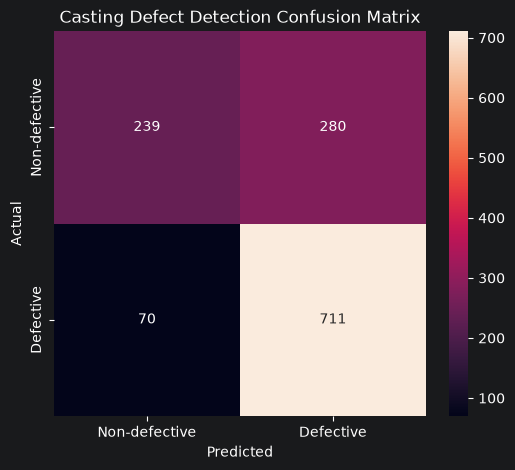

In [29]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    xticklabels=["Non-defective", "Defective"],
    yticklabels=["Non-defective", "Defective"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Casting Defect Detection Confusion Matrix")

plt.show()

In [30]:
tn, fp, fn, tp = matrix.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 239
False Positives: 280
False Negatives: 70
True Positives  : 711


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

probabilities = prediction_probabilities.flatten()

thresholds = [0.30, 0.40, 0.50, 0.60]

for threshold in thresholds:

    predictions = (
        probabilities >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        actual_labels,
        predictions
    )

    precision = precision_score(
        actual_labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        actual_labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        actual_labels,
        predictions,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        actual_labels,
        predictions
    ).ravel()

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"FP       : {fp}")
    print(f"FN       : {fn}")


Threshold: 0.3
Accuracy : 0.6008
Precision: 0.6008
Recall   : 1.0000
F1       : 0.7506
FP       : 519
FN       : 0

Threshold: 0.4
Accuracy : 0.6008
Precision: 0.6008
Recall   : 1.0000
F1       : 0.7506
FP       : 519
FN       : 0

Threshold: 0.5
Accuracy : 0.7308
Precision: 0.7175
Recall   : 0.9104
F1       : 0.8025
FP       : 280
FN       : 70

Threshold: 0.6
Accuracy : 0.7223
Precision: 0.7877
Recall   : 0.7362
F1       : 0.7611
FP       : 155
FN       : 206
